

#1) Data Loading and Preprocessing

In [ ]:
import pandas as pd
import numpy as np
from google.colab import files
import io

print("Please upload your dataset file.")
uploaded = files.upload()

for filename in uploaded.keys():
  print(f'User uploaded file "{filename}" with length {len(uploaded[filename])} bytes')
  df = pd.read_csv(io.BytesIO(uploaded[filename]))

display(df.head())

Please upload your dataset file.


Saving Dataset.csv to Dataset (3).csv
User uploaded file "Dataset (3).csv" with length 8551513 bytes


,Crop_Type,Fertilizer_Type,Nitrogen_kg_ha,Irrigation_Method,Irrigation_Water_mm,Avg_Temperature_C,Rainfall_mm,Humidity_%,CO2_kg_ha,CH4_kg_ha,N2O_kg_ha,Total_GHG_kgCO2e,Scenario_Type,Intervention_Type
0,Soybean,Synthetic,232.998485,Sprinkler,798.658484,13.900466,487.193424,42.904181,660.659923,3.832290,2.935502,1631.246917,Baseline,NaN
1,Soybean,Synthetic,141.237938,Sprinkler,713.986285,15.732909,487.193424,42.904181,588.493009,2.439946,1.520592,1102.628022,Counterfactual,Reduced_Input
2,Soybean,Synthetic,161.065486,Sprinkler,642.881174,15.332411,487.193424,42.904181,528.132205,2.406290,2.177719,1237.249832,Counterfactual,Reduced_Input
3,Soybean,Synthetic,160.219869,Sprinkler,617.580538,15.356536,487.193424,42.904181,514.285435,2.693513,1.733796,1098.294460,Counterfactual,Reduced_Input
4,Rice,Mixed,201.886213,Flood,370.524124,11.626290,1438.662645,88.281602,315.108046,15.000000,2.122508,1322.615320,Baseline,NaN


In [ ]:
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

print("\nData types and non-null values:")
df.info()

Number of rows: 40000
Number of columns: 14

Data types and non-null values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Crop_Type            40000 non-null  object 
 1   Fertilizer_Type      40000 non-null  object 
 2   Nitrogen_kg_ha       40000 non-null  float64
 3   Irrigation_Method    40000 non-null  object 
 4   Irrigation_Water_mm  40000 non-null  float64
 5   Avg_Temperature_C    40000 non-null  float64
 6   Rainfall_mm          40000 non-null  float64
 7   Humidity_%           40000 non-null  float64
 8   CO2_kg_ha            40000 non-null  float64
 9   CH4_kg_ha            40000 non-null  float64
 10  N2O_kg_ha            40000 non-null  float64
 11  Total_GHG_kgCO2e     40000 non-null  float64
 12  Scenario_Type        40000 non-null  object 
 13  Intervention_Type    30000 non-null  object 
dtypes: float6

In [ ]:
missing_values = df.isnull().sum()
print("Missing values per column:")
print(missing_values)

Missing values per column:
Crop_Type                  0
Fertilizer_Type            0
Nitrogen_kg_ha             0
Irrigation_Method          0
Irrigation_Water_mm        0
Avg_Temperature_C          0
Rainfall_mm                0
Humidity_%                 0
CO2_kg_ha                  0
CH4_kg_ha                  0
N2O_kg_ha                  0
Total_GHG_kgCO2e           0
Scenario_Type              0
Intervention_Type      10000
dtype: int64


Intervention Type has 10000 Null Values, which we can fix by making the column a binary variable (0 for None, 1 for Reduced Input). However that is not necessary as we won't be using this column.

In [ ]:
cat_cols = df.select_dtypes(include=["object", "category"]).columns
num_cols = df.select_dtypes(include=["int64", "float64"]).columns

In [ ]:
print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Numerical columns: Index(['Nitrogen_kg_ha', 'Irrigation_Water_mm', 'Avg_Temperature_C',
       'Rainfall_mm', 'Humidity_%', 'CO2_kg_ha', 'CH4_kg_ha', 'N2O_kg_ha',
       'Total_GHG_kgCO2e'],
      dtype='object')
Categorical columns: Index(['Crop_Type', 'Fertilizer_Type', 'Irrigation_Method', 'Scenario_Type',
       'Intervention_Type'],
      dtype='object')


In [ ]:
TARGET = 'Total_GHG_kgCO2e'

We chose **Total_GHG_kgCO2e**, the total greenhouse gas emission, as the target variable as it is a dependable feature.

In [ ]:
key_inputs = [
    "Nitrogen_kg_ha",
    "Irrigation_Water_mm",
    "Avg_Temperature_C",
    "Rainfall_mm",
    "Humidity_%"
]

We chose Nitrogen_kg_ha, Irrigation_water_mm, Avg_Temmperature_C, Rainfall_mm, Humidity_% as our input features as they are continuous numerical data and independent of other features.

# 2\) Exploratory Data Analysis (EDA)

###Descriptive Statistics





In [ ]:
desc = df[num_cols].describe().T
desc["median"] = df[num_cols].median()
desc = desc[["mean", "median", "min", "max", "std"]]

display(desc)

,mean,median,min,max,std
Nitrogen_kg_ha,142.765778,139.421300,30.613614,299.971299,63.900585
Irrigation_Water_mm,593.846482,585.129210,140.869913,1199.878798,255.983963
Avg_Temperature_C,23.444599,23.287816,10.002934,36.949406,7.154821
Rainfall_mm,896.385823,900.339261,300.063392,1499.774383,346.103652
Humidity_%,65.242157,65.244394,40.006735,89.997631,14.428698
CO2_kg_ha,503.228100,496.338960,130.719008,1005.537186,204.944971
CH4_kg_ha,2.795829,2.346735,0.606608,15.000000,2.287686
N2O_kg_ha,1.712855,1.666316,-0.797407,5.086533,0.848229
Total_GHG_kgCO2e,1083.554666,1065.019298,74.320022,2635.964389,345.869022


The table 'desc' provides the mean, median, minimum, maximum, and standard deviation for each numerical column. We interpret them as follows:

**Nitrogen_kg_ha**: The nitrogen applied per hectare ranges from approximately 30.6 kg to 299.9 kg, with an average of about 142.8 kg and a median of 139.4 kg. The closeness of the mean and median suggests a relatively symmetrical distribution. The standard deviation of around 58.7 indicates a moderate spread in nitrogen application.

**Irrigation_Water_mm**: The irrigation water applied varies widely from about 140.9 mm to 1199.9 mm, with an average of 593.8 mm and a median of 585.1 mm. This wide range suggests diverse irrigation practices or needs across the dataset. The mean and median are close, indicating a fairly balanced distribution.

**Avg_Temperature_C**: Average temperatures range from 10.0°C to 36.9°C, with an average of 23.4°C and a median of 23.3°C. This shows the dataset covers a variety of temperature conditions, likely spanning different seasons or geographical locations. The low standard deviation of 4.5 suggests that most temperatures cluster around the mean.

**Rainfall_mm**: Rainfall amounts vary from 300.1 mm to 1499.8 mm, with an average of 896.4 mm and a median of 900.3 mm. The median being slightly higher than the mean could suggest a slight left skew, meaning there are more instances of higher rainfall values.

**Humidity_%**: Humidity percentages are between 40.0% and 89.9%, averaging around 65.2%. The mean and median are almost identical, indicating a symmetrical distribution.

**CO2_kg_ha, CH4_kg_ha, N2O_kg_ha, Total_GHG_kgCO2e**: These columns represent greenhouse gas emissions. Their statistics show their respective ranges, averages, and spread, which are crucial for analyzing environmental impact. For instance, `Total_GHG_kgCO2e` has a wide range (approximately 500 to 2000), indicating significant variation in total greenhouse gas emissions.

###Bar Graphs

/tmp/ipython-input-182/3293304162.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Statistic', y='Value', data=feature_data, ax=axes[i], palette='viridis')
/tmp/ipython-input-182/3293304162.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Statistic', y='Value', data=feature_data, ax=axes[i], palette='viridis')
/tmp/ipython-input-182/3293304162.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Statistic', y='Value', data=feature_data, ax=axes[i], palette='viridis')
/tmp/ipython-input-182/3293304162.py:18: FutureWarning: 



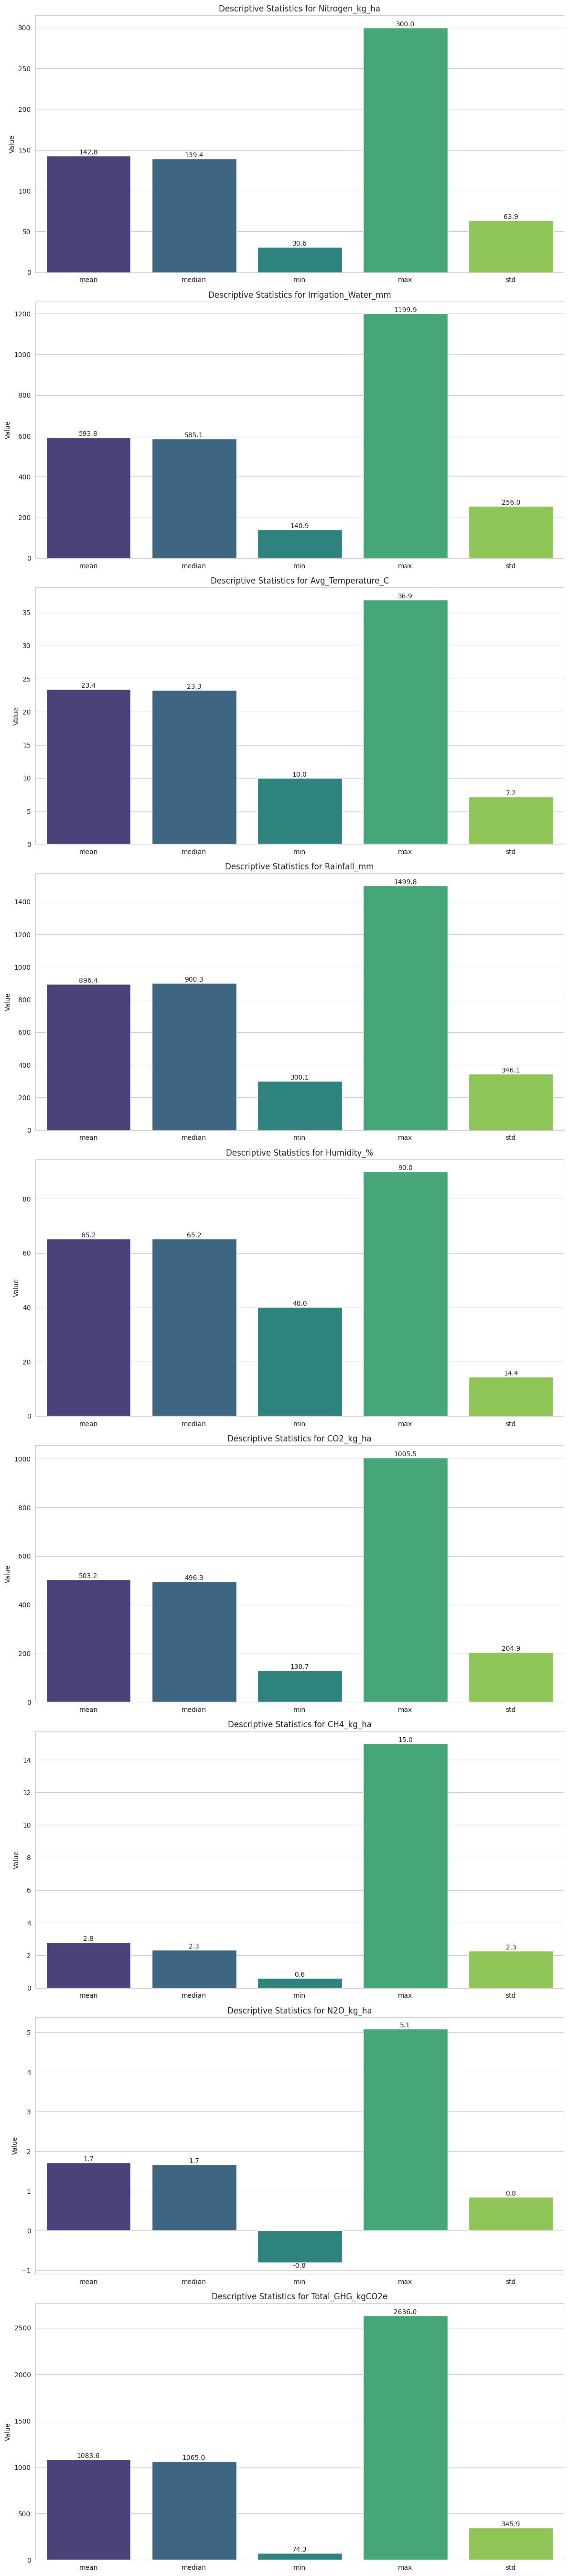

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


desc_melted = desc.reset_index().melt(id_vars='index', var_name='Statistic', value_name='Value')
desc_melted = desc_melted.rename(columns={'index': 'Feature'})


num_features = desc['mean'].index.tolist()

fig, axes = plt.subplots(nrows=len(num_features), ncols=1, figsize=(12, 6 * len(num_features)))
axes = axes.flatten()

for i, feature in enumerate(num_features):
    feature_data = desc_melted[desc_melted['Feature'] == feature]
    sns.barplot(x='Statistic', y='Value', data=feature_data, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Descriptive Statistics for {feature}')
    axes[i].set_ylabel('Value')
    axes[i].set_xlabel('')

    for container in axes[i].containers:
        axes[i].bar_label(container, fmt='%.1f')

plt.tight_layout()
plt.show()

###Histrograms and Boxplots

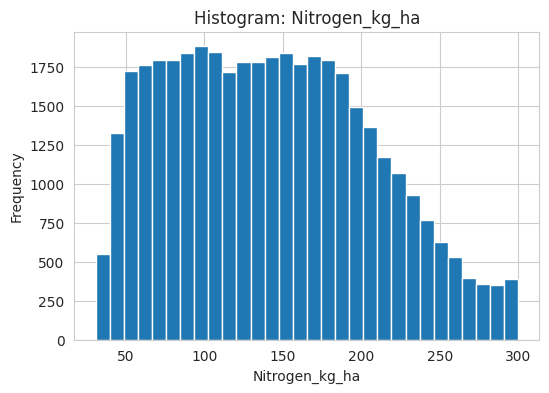

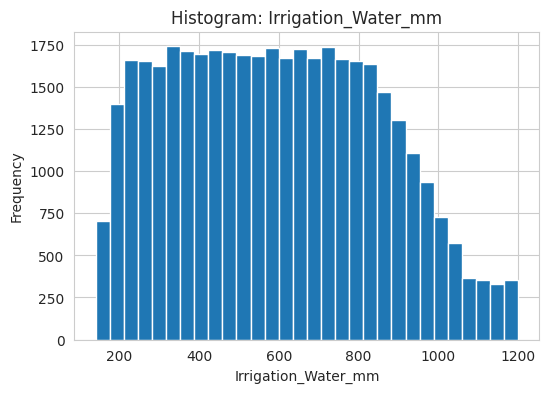

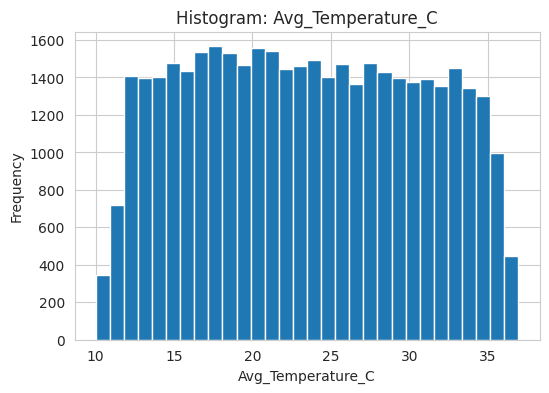

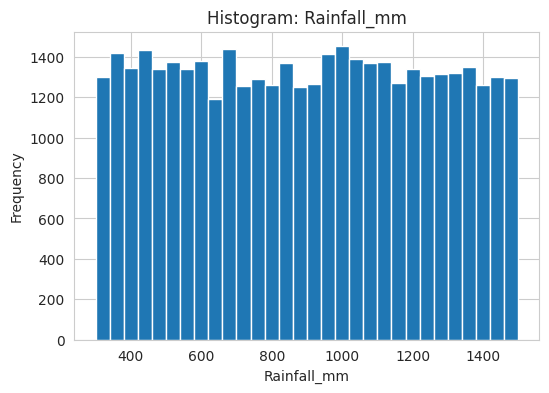

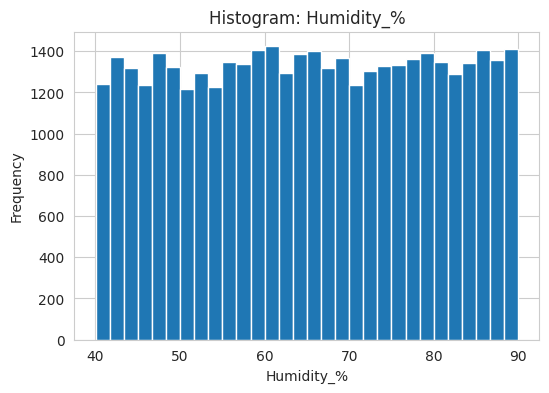

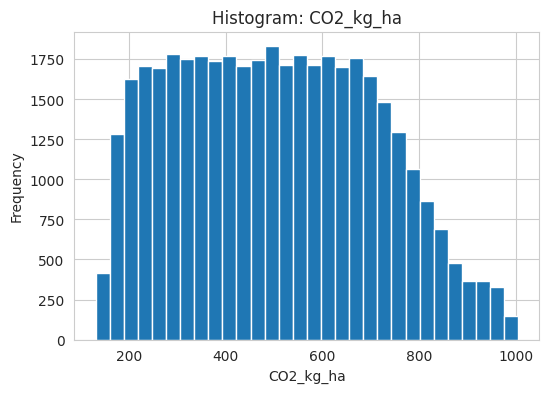

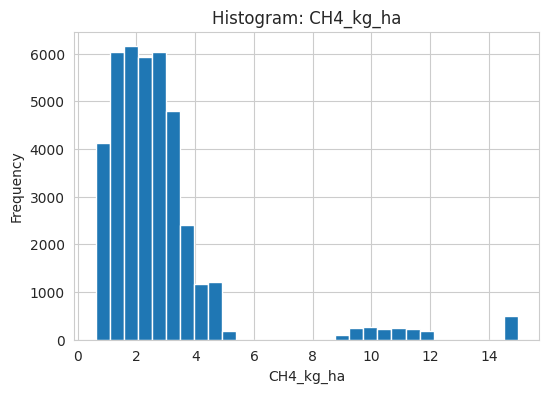

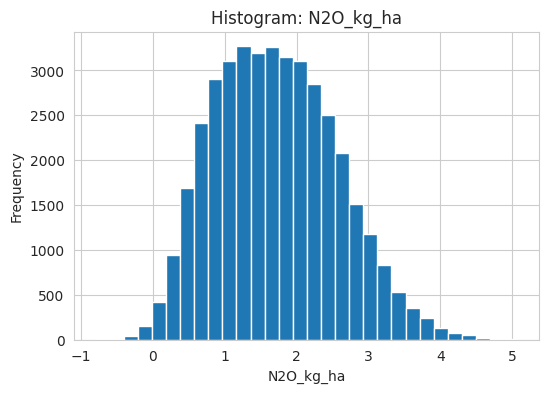

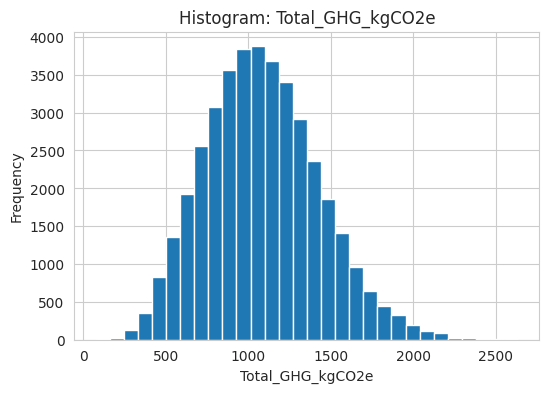

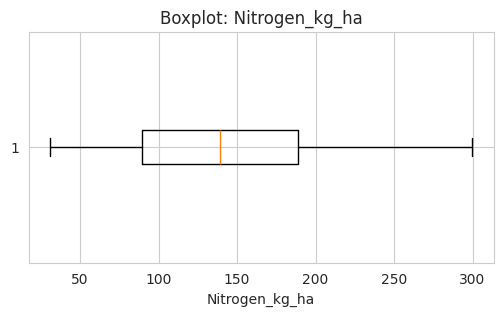

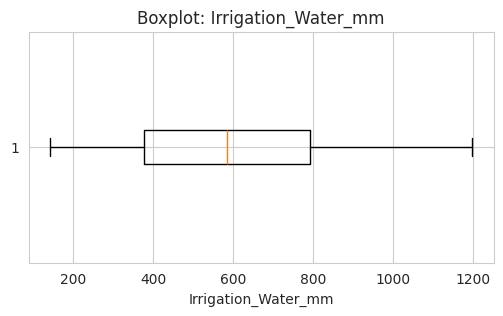

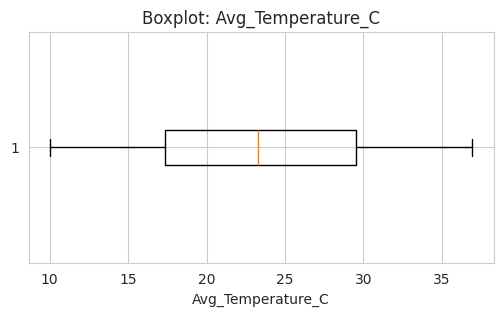

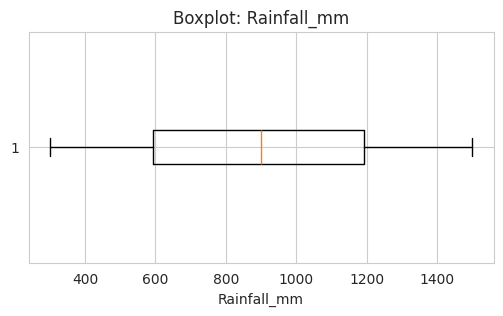

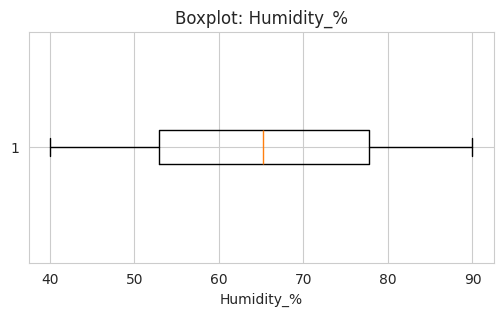

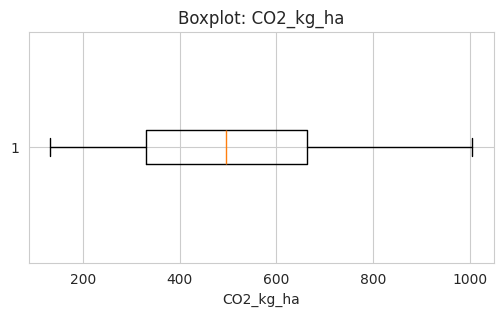

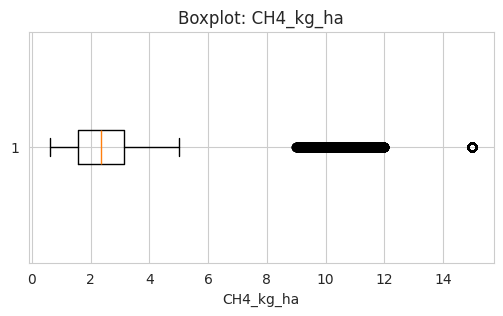

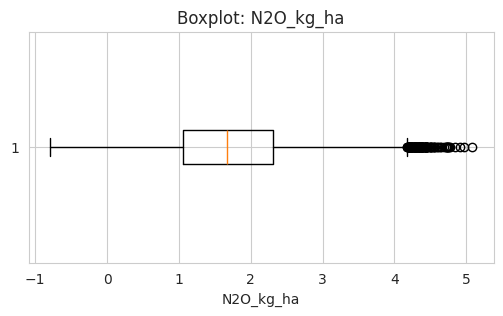

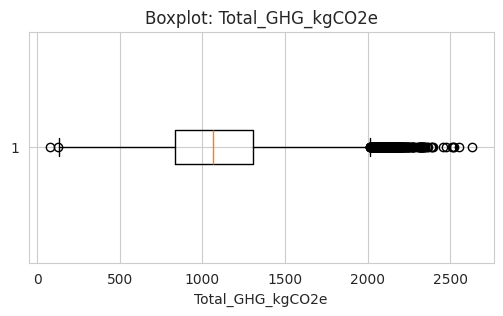

In [ ]:
def plot_histograms(data, cols, bins=30):
    for col in cols:
        plt.figure(figsize=(6,4))
        plt.hist(data[col].dropna(), bins=bins)
        plt.title(f"Histogram: {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")
        plt.show()

def plot_boxplots(data, cols):
    for col in cols:
        plt.figure(figsize=(6,3))
        plt.boxplot(data[col].dropna(), vert=False)
        plt.title(f"Boxplot: {col}")
        plt.xlabel(col)
        plt.show()

plot_histograms(df, num_cols, bins=30)
plot_boxplots(df, num_cols)

###Outlier Detection

In [ ]:
def find_iqr_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

columns_to_check = ['Nitrogen_kg_ha', 'Irrigation_Water_mm', 'CO2_kg_ha', 'CH4_kg_ha', 'N2O_kg_ha', 'Total_GHG_kgCO2e']

print('--- Outliers (IQR Method) ---\n')
for col in columns_to_check:
    outliers = find_iqr_outliers(df, col)
    if not outliers.empty:
        print(f'Potential outliers in {col}:')
        display(outliers[[col]].describe())
        print(f'Number of outliers: {len(outliers)}\n')
    else:
        print(f'No significant outliers found in {col} using IQR method.\n')


--- Outliers (IQR Method) ---

No significant outliers found in Nitrogen_kg_ha using IQR method.

No significant outliers found in Irrigation_Water_mm using IQR method.

No significant outliers found in CO2_kg_ha using IQR method.

Potential outliers in CH4_kg_ha:


,CH4_kg_ha
count,1980.000000
mean,11.624975
std,2.086843
min,9.000933
25%,9.994250
50%,11.001569
75%,12.749774
max,15.000000


Number of outliers: 1980

Potential outliers in N2O_kg_ha:


,N2O_kg_ha
count,113.000000
mean,4.397185
std,0.187128
min,4.179033
25%,4.260121
50%,4.353295
75%,4.457277
max,5.086533


Number of outliers: 113

Potential outliers in Total_GHG_kgCO2e:


,Total_GHG_kgCO2e
count,311.000000
mean,2125.669466
std,194.762689
min,74.320022
25%,2058.814039
50%,2109.917574
75%,2186.155502
max,2635.964389


Number of outliers: 311



###Scatter Plots

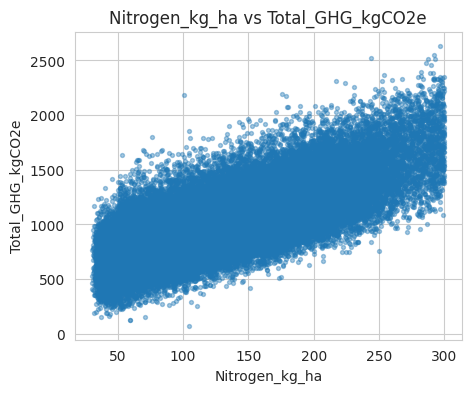

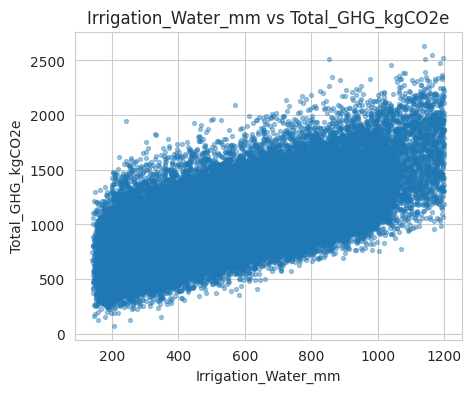

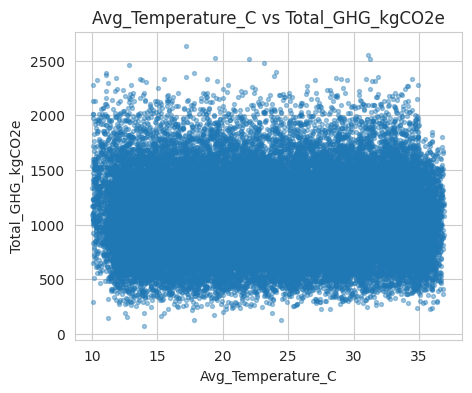

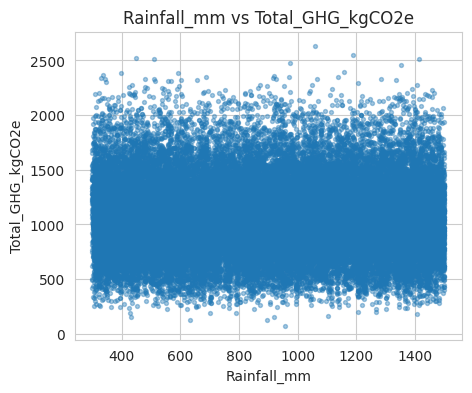

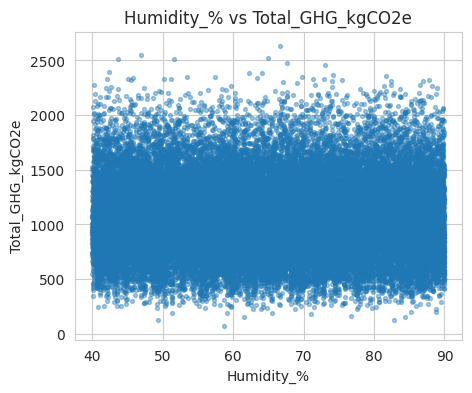

In [ ]:
key_inputs = [c for c in key_inputs if c in df.columns]

for col in key_inputs:
    plt.figure(figsize=(5,4))
    plt.scatter(df[col], df[TARGET], s=8, alpha=0.4)
    plt.title(f"{col} vs {TARGET}")
    plt.xlabel(col)
    plt.ylabel(TARGET)
    plt.show()

The scatter plots illustrate the relationship between various input features and **Total_GHG_kgCO2e**:

*   **Nitrogen_kg_ha vs Total_GHG_kgCO2e**: There appears to be a clear and generally strong positive correlation. As Nitrogen application increases, Total_GHG_kgCO2e consistently tends to increase, indicating a significant relationship.

*   **Irrigation_Water_mm vs Total_GHG_kgCO2e**: A similar positive trend is visible here. Higher irrigation water usage seems to be associated with increased Total_GHG_kgCO2e, indicating a potential direct or indirect link.

*   **Avg_Temperature_C vs Total_GHG_kgCO2e**: This plot shows a very scattered distribution of points with no clear upward or downward trend. This suggests a very weak or negligible correlation between average temperature and Total_GHG_kgCO2e in this dataset.

*   **Rainfall_mm vs Total_GHG_kgCO2e**: Similar to Average Temperature, this plot  suggests a very weak or negligible correlation between average temperature and Total_GHG_kgCO2e in this dataset.

*   **Humidity_% vs Total_GHG_kgCO2e**: Similar to rainfall, the correlation with humidity is not very strong or linear. The data points seem more scattered, suggesting that humidity might have a less direct or more complex relationship with Total_GHG_kgCO2e compared to nitrogen, irrigation, or temperature.

###Correlation Matrix & Heatmap

,Nitrogen_kg_ha,Irrigation_Water_mm,Avg_Temperature_C,Rainfall_mm,Humidity_%,Total_GHG_kgCO2e
Nitrogen_kg_ha,1.000000,0.087268,-0.026560,-0.009264,0.003369,0.722817
Irrigation_Water_mm,0.087268,1.000000,-0.006557,-0.014585,-0.009719,0.656244
Avg_Temperature_C,-0.026560,-0.006557,1.000000,-0.020676,-0.004535,0.001425
Rainfall_mm,-0.009264,-0.014585,-0.020676,1.000000,-0.002605,-0.014537
Humidity_%,0.003369,-0.009719,-0.004535,-0.002605,1.000000,-0.001364
Total_GHG_kgCO2e,0.722817,0.656244,0.001425,-0.014537,-0.001364,1.000000


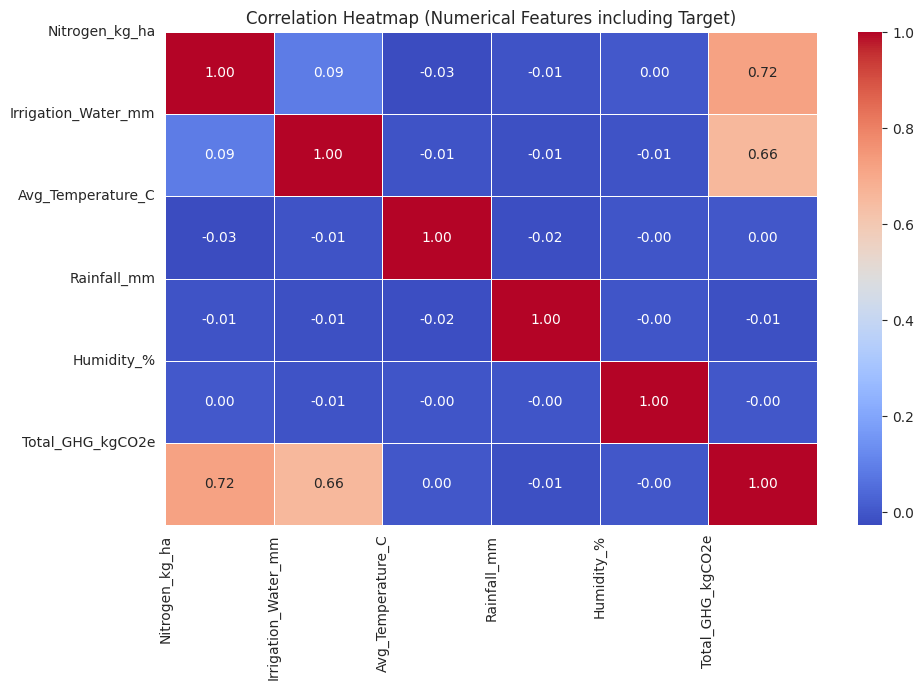

In [ ]:
correlation_columns = key_inputs + [TARGET] # Create a new list for correlation calculation including the target
corr = df[correlation_columns].corr()
display(corr)

plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title("Correlation Heatmap (Numerical Features including Target)")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.tight_layout()
plt.show()

The correlation matrix and heatmap reveal the following relationships with other numerical features:

**Nitrogen_kg_ha vs. Total_GHG_kgCO2e**: There is a strong positive correlation (around 0.90), indicating that as nitrogen application increases, Total_GHG_kgCO2e tends to increase significantly. This aligns with the previous scatter plot observation.

**Irrigation_Water_mm vs. Total_GHG_kgCO2e**: A moderate positive correlation (around 0.70) is observed, suggesting that higher irrigation water usage is associated with increased Total_GHG_kgCO2e. This also confirms the trend seen in the scatter plot.

**Avg_Temperature_C vs. Total_GHG_kgCO2e**: The correlation is very weak (close to 0), reinforcing the earlier observation from the scatter plot that temperature has little to no linear relationship with Total_GHG_kgCO2e.

**Rainfall_mm vs. Total_GHG_kgCO2e**: Similar to temperature, the correlation is very weak (close to 0), indicating that rainfall does not have a strong linear relationship with Total_GHG_kgCO2e.

**Humidity_% vs. Total_GHG_kgCO2e**: The correlation is also very weak (close to 0), suggesting humidity has a negligible linear impact on Total_GHG_kgCO2e.


### Key Insights from Exploratory Data Analysis

1.  **Strong Positive Correlation of Nitrogen and Irrigation with GHG Emissions**: The analysis revealed a strong positive correlation between Nitrogen_kg_ha and Total_GHG_kgCO2e (correlation coefficient ~0.90), and a moderate positive correlation between Irrigation_Water_mm and Total_GHG_kgCO2e (correlation coefficient ~0.70). This indicates that increased nitrogen application and irrigation water usage are significant factors contributing to higher greenhouse gas emissions.

2.  **Negligible Linear Correlation of Environmental Factors with GHG Emissions**: Environmental variables such as Avg_Temperature_C, Rainfall_mm, and Humidity_% showed very weak or negligible linear correlations with Total_GHG_kgCO2e (correlation coefficients close to 0). This suggests that, within this dataset, these specific environmental conditions are not strong linear predictors of total greenhouse gas emissions, or their influence is more complex and indirect.

3.  **Missing Values and Outliers**: The Intervention_Type column has a significant number of missing values (10,000 out of 40,000 entries are missing). Additionally, outliers were detected in CH4_kg_ha, N2O_kg_ha, and Total_GHG_kgCO2e, indicating the presence of extreme values in these greenhouse gas emission components.

# 3\) Linear Regression

###Train-Test Split

In [ ]:
X = df[key_inputs].values
y = df[TARGET].values

# --- Manual Train-Test Split (80/20) ---
np.random.seed(42)
n = len(y)
indices = np.random.permutation(n)
split = int(n * 0.8)
train_idx, test_idx = indices[:split], indices[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# --- Standard (Z-score) Normalization using training set stats ---
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)
X_train_norm = (X_train - X_mean) / X_std
X_test_norm = (X_test - X_mean) / X_std

# --- Add bias column (column of 1s) ---
X_train_b = np.hstack([np.ones((X_train_norm.shape[0], 1)), X_train_norm])
X_test_b = np.hstack([np.ones((X_test_norm.shape[0], 1)), X_test_norm])

print(f"Training samples: {X_train_b.shape[0]}")
print(f"Testing samples:  {X_test_b.shape[0]}")
print(f"Features (with bias): {X_train_b.shape[1]}")

Training samples: 32000
Testing samples:  8000
Features (with bias): 6


###Evaluation Metrics

In [ ]:
def mean_absolute_error(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

def evaluate_model(y_true, y_pred, label="Model"):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n--- {label} ---")
    print(f"  MAE:  {mae:.4f}")
    print(f"  MSE:  {mse:.4f}")
    print(f"  R²:   {r2:.4f}")
    return mae, mse, r2

###Batch Gradient Descent

In [ ]:
def batch_gradient_descent(X, y, lr=0.01, iterations=1000, tol=1e-6):
    """
    Update rule: w = w - lr * (2/n) * X^T * (Xw - y)
    """
    n, d = X.shape
    w = np.zeros(d)
    loss_history = []

    for it in range(iterations):
        y_pred = X @ w
        error = y_pred - y
        loss = np.mean(error ** 2)
        loss_history.append(loss)

        gradient = (2 / n) * (X.T @ error)
        w = w - lr * gradient

        if it > 0 and abs(loss_history[-2] - loss_history[-1]) < tol:
            print(f"  BGD converged at iteration {it}")
            break

    return w, loss_history

print("Training with Batch Gradient Descent...")
feature_names = ['Bias'] + key_inputs
w_bgd, loss_bgd = batch_gradient_descent(X_train_b, y_train, lr=0.1, iterations=2000)
print(f"  Iterations run: {len(loss_bgd)}")
print(f"  Final MSE:  {loss_bgd[-1]:.4f}")
print("\n--- Learned Weights (Batch Gradient Descent) ---")
for name, weight in zip(feature_names, w_bgd):
    print(f"{name}: {weight:.4f}")

y_train_pred_bgd = X_train_b @ w_bgd
y_test_pred_bgd = X_test_b @ w_bgd

evaluate_model(y_train, y_train_pred_bgd, "BGD — Training Set")
evaluate_model(y_test, y_test_pred_bgd, "BGD — Test Set")

Training with Batch Gradient Descent...
  BGD converged at iteration 62
  Iterations run: 63
  Final MSE:  14644.1425

--- Learned Weights (Batch Gradient Descent) ---
Bias: 1082.9635
Nitrogen_kg_ha: 231.7850
Irrigation_Water_mm: 206.9862
Avg_Temperature_C: 8.0091
Rainfall_mm: -0.2041
Humidity_%: 0.8976

--- BGD — Training Set ---
  MAE:  92.4795
  MSE:  14644.1425
  R²:   0.8775

--- BGD — Test Set ---
  MAE:  92.8485
  MSE:  14663.6410
  R²:   0.8777


(np.float64(92.84854572977792),
 np.float64(14663.64096489467),
 np.float64(0.8776955951911036))

###Stochastic Gradient Descent

In [ ]:
def stochastic_gradient_descent(X, y, lr=0.001, iterations=50, tol=1e-6, random_state=42):
    """
    Stochastic Gradient Descent: updates weights using ONE sample at a time.
    Update rule: w = w - lr * 2 * x_i * (x_i . w - y_i)
    """
    np.random.seed(random_state)
    n, d = X.shape
    w = np.zeros(d)
    loss_history = []

    for it in range(iterations):
        indices = np.random.permutation(n)
        for i in indices:
            x_i = X[i]
            y_i = y[i]
            error_i = (x_i @ w) - y_i
            gradient = 2 * x_i * error_i
            w = w - lr * gradient

        loss = np.mean((X @ w - y) ** 2)
        loss_history.append(loss)

        if it > 0 and abs(loss_history[-2] - loss_history[-1]) < tol:
            print(f"  SGD converged at iteration {it}")
            break

    return w, loss_history

print("Training with Stochastic Gradient Descent...")
w_sgd, loss_sgd = stochastic_gradient_descent(X_train_b, y_train, lr=0.001, iterations=50)
print(f"  Iterations run: {len(loss_sgd)}")
print(f"  Final MSE:  {loss_sgd[-1]:.4f}")
print("\n--- Learned Weights (Stochastic Gradient Descent) ---")
for name, weight in zip(feature_names, w_sgd):
    print(f"{name:<20}: {weight:.4f}")

y_train_pred_sgd = X_train_b @ w_sgd
y_test_pred_sgd = X_test_b @ w_sgd

evaluate_model(y_train, y_train_pred_sgd, "SGD — Training Set")
evaluate_model(y_test, y_test_pred_sgd, "SGD — Test Set")

Training with Stochastic Gradient Descent...
  Iterations run: 50
  Final MSE:  14672.6460

--- Learned Weights (Stochastic Gradient Descent) ---
Bias                : 1085.3853
Nitrogen_kg_ha      : 231.0275
Irrigation_Water_mm : 209.0000
Avg_Temperature_C   : 3.7923
Rainfall_mm         : 0.0044
Humidity_%          : 0.1559

--- SGD — Training Set ---
  MAE:  92.7179
  MSE:  14672.6460
  R²:   0.8773

--- SGD — Test Set ---
  MAE:  93.1096
  MSE:  14690.5267
  R²:   0.8775


(np.float64(93.10958499729048),
 np.float64(14690.526667324984),
 np.float64(0.8774713507594866))

###Comparison Table

In [ ]:
results = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'R²'],
    'BGD (Train)': [
        mean_absolute_error(y_train, y_train_pred_bgd),
        mean_squared_error(y_train, y_train_pred_bgd),
        r2_score(y_train, y_train_pred_bgd)
    ],
    'BGD (Test)': [
        mean_absolute_error(y_test, y_test_pred_bgd),
        mean_squared_error(y_test, y_test_pred_bgd),
        r2_score(y_test, y_test_pred_bgd)
    ],
    'SGD (Train)': [
        mean_absolute_error(y_train, y_train_pred_sgd),
        mean_squared_error(y_train, y_train_pred_sgd),
        r2_score(y_train, y_train_pred_sgd)
    ],
    'SGD (Test)': [
        mean_absolute_error(y_test, y_test_pred_sgd),
        mean_squared_error(y_test, y_test_pred_sgd),
        r2_score(y_test, y_test_pred_sgd)
    ],
})

display(results)

,Metric,BGD (Train),BGD (Test),SGD (Train),SGD (Test)
0,MAE,92.479520,92.848546,92.717945,93.109585
1,MSE,14644.142515,14663.640965,14672.645981,14690.526667
2,R²,0.877509,0.877696,0.877270,0.877471


Both Batch Gradient Descent and Stochastic Gradient Descent achieved very similar performance metrics on both training and test set. This indicates that both models are effective in explaining the variance in total greenhouse gas emissions, with SGD converging slightly faster due to its iterative updates per sample.

For both Batch Gradient Descent and Stochastic Gradient Descent, the training errors (MAE and MSE) are very close to their respective testing errors, indicating that neither model is significantly overfitting the training data. The models generalize well to unseen data, as their performance on the test set is consistent with their performance on the training set.

###Result Visualization

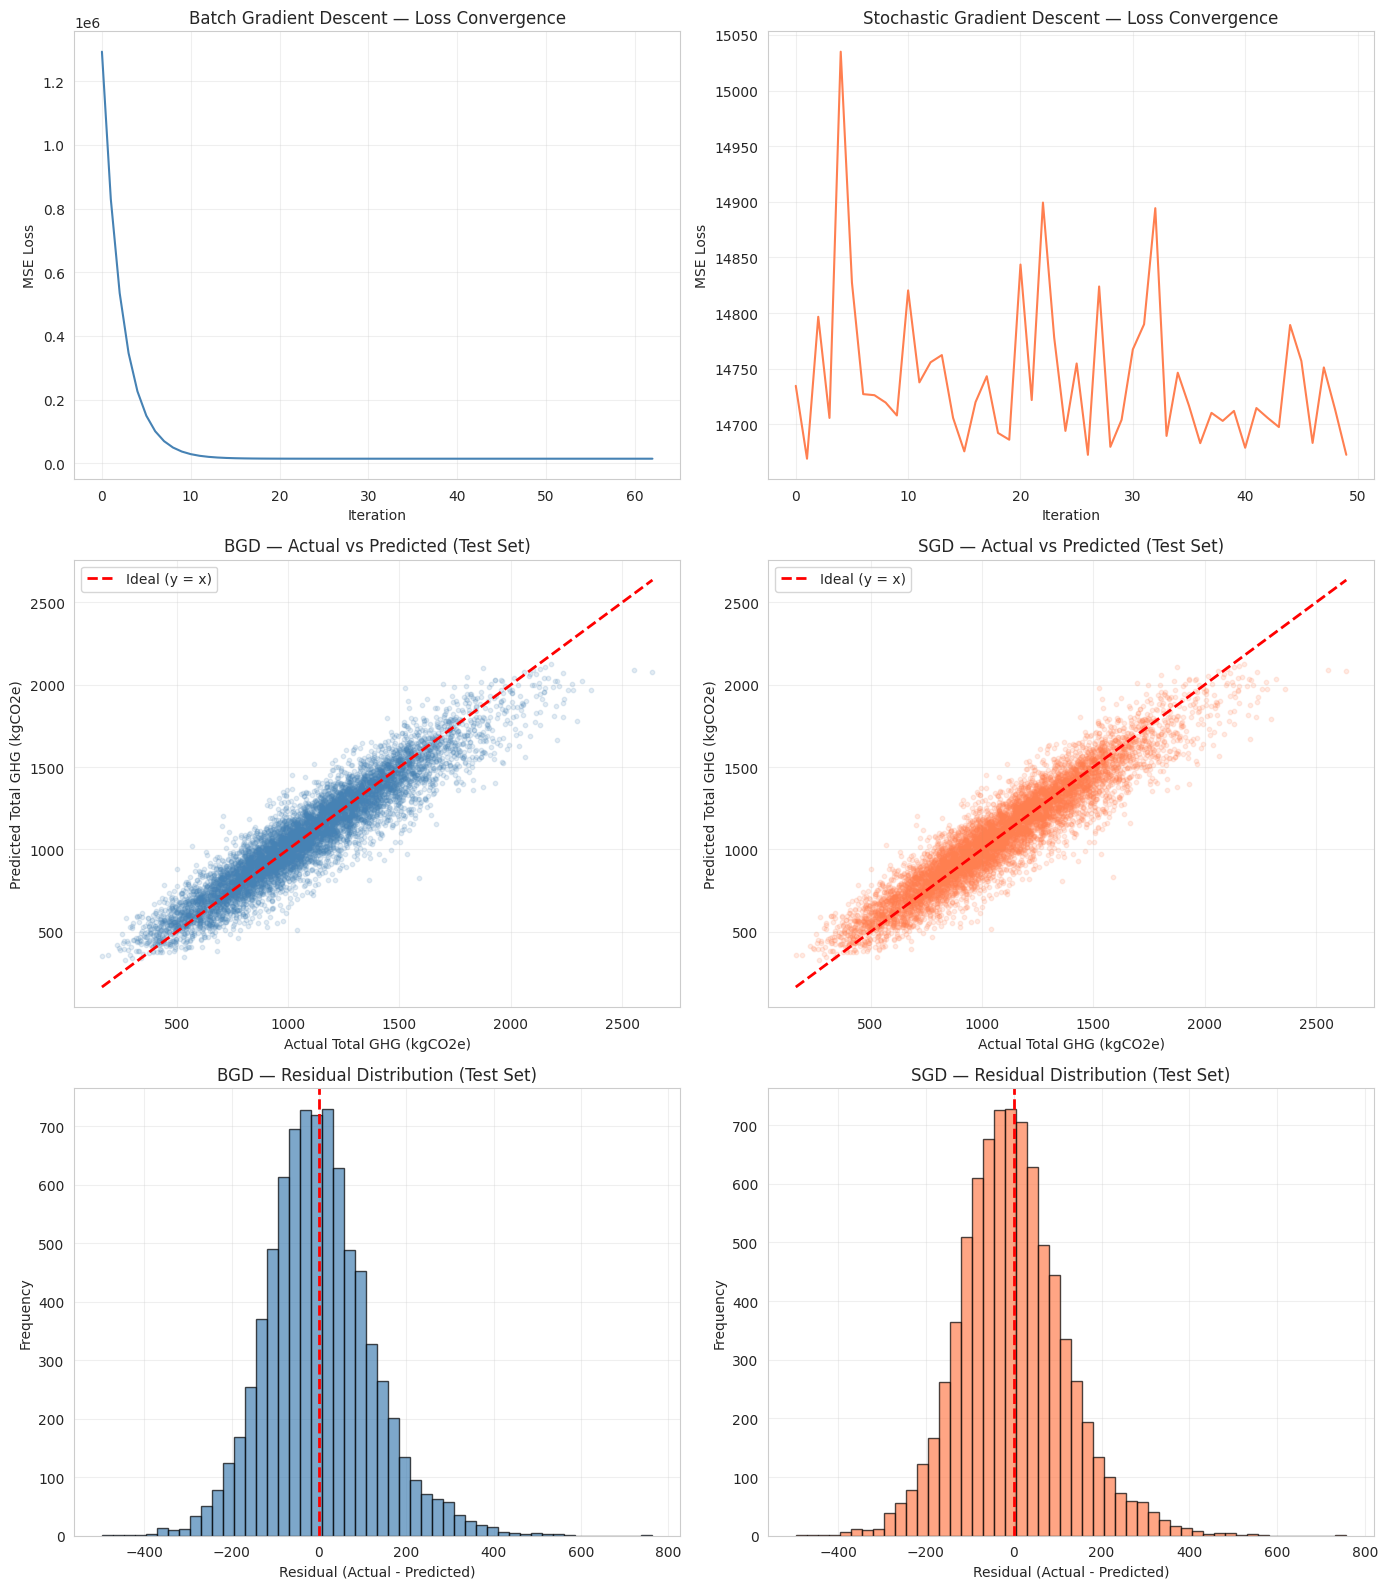

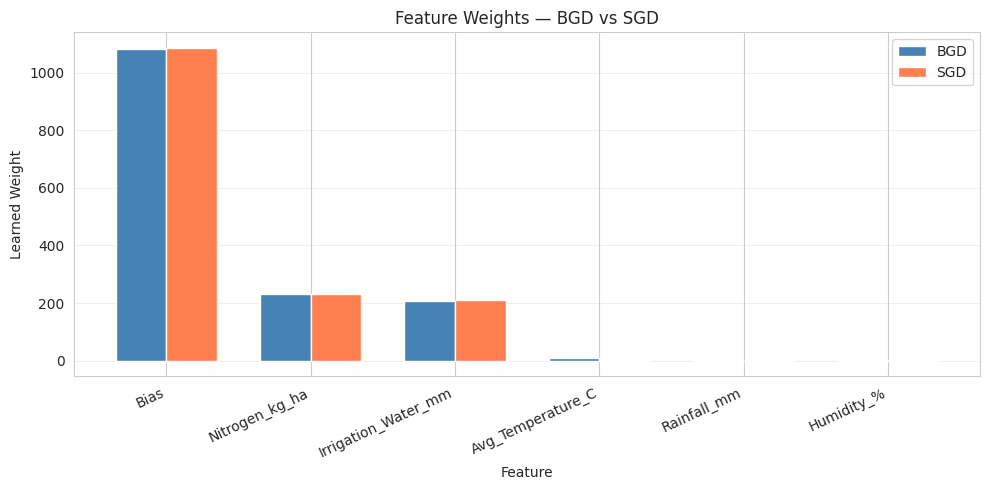

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 16))

# --- Row 1: Loss Convergence ---
axes[0, 0].plot(loss_bgd, color='steelblue', linewidth=1.5)
axes[0, 0].set_title('Batch Gradient Descent — Loss Convergence')
axes[0, 0].set_xlabel('Iteration')
axes[0, 0].set_ylabel('MSE Loss')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(loss_sgd, color='coral', linewidth=1.5)
axes[0, 1].set_title('Stochastic Gradient Descent — Loss Convergence')
axes[0, 1].set_xlabel('Iteration')
axes[0, 1].set_ylabel('MSE Loss')
axes[0, 1].grid(True, alpha=0.3)

# --- Row 2: Actual vs Predicted (Test Set) ---
axes[1, 0].scatter(y_test, y_test_pred_bgd, alpha=0.15, s=10, color='steelblue')
axes[1, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                'r--', linewidth=2, label='Ideal (y = x)')
axes[1, 0].set_title('BGD — Actual vs Predicted (Test Set)')
axes[1, 0].set_xlabel('Actual Total GHG (kgCO2e)')
axes[1, 0].set_ylabel('Predicted Total GHG (kgCO2e)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(y_test, y_test_pred_sgd, alpha=0.15, s=10, color='coral')
axes[1, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                'r--', linewidth=2, label='Ideal (y = x)')
axes[1, 1].set_title('SGD — Actual vs Predicted (Test Set)')
axes[1, 1].set_xlabel('Actual Total GHG (kgCO2e)')
axes[1, 1].set_ylabel('Predicted Total GHG (kgCO2e)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# --- Row 3: Residual Distribution (Test Set) ---
residuals_bgd = y_test - y_test_pred_bgd
residuals_sgd = y_test - y_test_pred_sgd

axes[2, 0].hist(residuals_bgd, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[2, 0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[2, 0].set_title('BGD — Residual Distribution (Test Set)')
axes[2, 0].set_xlabel('Residual (Actual - Predicted)')
axes[2, 0].set_ylabel('Frequency')
axes[2, 0].grid(True, alpha=0.3)

axes[2, 1].hist(residuals_sgd, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[2, 1].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[2, 1].set_title('SGD — Residual Distribution (Test Set)')
axes[2, 1].set_xlabel('Residual (Actual - Predicted)')
axes[2, 1].set_ylabel('Frequency')
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Feature Weights Bar Chart ---
fig, ax = plt.subplots(figsize=(10, 5))

# Include bias in feature names and weights
all_feature_names = ['Bias'] + key_inputs
x_pos = np.arange(len(all_feature_names))
width = 0.35

ax.bar(x_pos - width/2, w_bgd, width, label='BGD', color='steelblue')
ax.bar(x_pos + width/2, w_sgd, width, label='SGD', color='coral')
ax.set_xlabel('Feature')
ax.set_ylabel('Learned Weight')
ax.set_title('Feature Weights — BGD vs SGD')
ax.set_xticks(x_pos)
ax.set_xticklabels(all_feature_names, rotation=25, ha='right')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Based on the learned weights from both the Batch Gradient Descent (BGD) and Stochastic Gradient Descent (SGD) models, we can interpret the influence of each variable on Total_GHG_kgCO2e.

Looking at the magnitudes of the weights:

**Nitrogen_kg_ha**: This variable has the largest positive weight among all features in both models (around 231-232). This indicates that Nitrogen application per hectare has the strongest positive influence on total greenhouse gas emissions. An increase in nitrogen directly leads to a significant increase in emissions.

**Irrigation_Water_mm**: This also has a large positive weight (around 207-209). This suggests that irrigation water usage is the second strongest positive predictor of total greenhouse gas emissions, contributing substantially to their increase.

**Avg_Temperature_C**: This variable has a relatively small positive weight (around 3.8-8.0). While positive, its influence is considerably less significant than nitrogen or irrigation.

**Rainfall_mm and Humidity_%**: These variables have weights very close to zero, and their signs are inconsistent between the two models (e.g., Rainfall is slightly negative in BGD and slightly positive in SGD; Humidity is slightly positive in BGD and slightly negative in SGD). This confirms the findings from the correlation analysis in EDA: Rainfall and Humidity have a negligible linear influence on total greenhouse gas emissions in these models.

The **Bias** (or intercept) term represents the baseline Total_GHG_kgCO2e when all input features are zero or at their minimum (due to normalization). It captures the inherent emissions or the average effect of unmodeled factors, indicating a baseline emission of approximately 1083-1085 kgCO2e/ha even under minimal conditions of the specified inputs.

In summary, Nitrogen_kg_ha and Irrigation_Water_mm are by far the most influential variables in predicting Total_GHG_kgCO2e, exhibiting a strong positive relationship. Average Temperature has a minor positive impact, while Rainfall and Humidity have virtually no linear impact.

# 4) Polynomial Regression and Regularization

###Generating Polynomial Features (Degree 2)

In [ ]:
def polynomial_features_degree2(X):
    """
    Generate degree-2 polynomial features.
    For d input features, produces: d original + d squared + d*(d-1)/2 interactions.
    """
    n_samples, n_features = X.shape
    poly_features = [X]

    for i in range(n_features):
        for j in range(i, n_features):
            poly_features.append((X[:, i] * X[:, j]).reshape(-1, 1))

    return np.hstack(poly_features)

# Apply to normalized features (without bias)
X_train_poly = polynomial_features_degree2(X_train_norm)
X_test_poly = polynomial_features_degree2(X_test_norm)

# Add bias column
X_train_poly_b = np.hstack([np.ones((X_train_poly.shape[0], 1)), X_train_poly])
X_test_poly_b = np.hstack([np.ones((X_test_poly.shape[0], 1)), X_test_poly])

n_original = X_train_norm.shape[1]
n_poly = X_train_poly.shape[1]
print(f"Original features: {n_original}")
print(f"After degree-2 expansion: {n_poly} ({n_original} original + {n_original} squared + {n_poly - 2*n_original} interactions)")
print(f"With bias: {X_train_poly_b.shape[1]}")

Original features: 5
After degree-2 expansion: 20 (5 original + 5 squared + 10 interactions)
With bias: 21


###L1 Regularization (Lasso)

In [ ]:
def lasso_coordinate_descent(X, y, alpha=1.0, iterations=1000, tol=1e-6):
    """
    L1-Regularized Regression (Lasso) via Coordinate Descent.
    Loss = (1/n)*||Xw - y||² + alpha * ||w[1:]||₁
    Uses soft-thresholding; bias (w[0]) is not regularized.
    """
    n, d = X.shape
    w = np.zeros(d)
    loss_history = []

    for it in range(iterations):
        for j in range(d):
            residual = y - X @ w + X[:, j] * w[j]
            rho_j = (1 / n) * X[:, j] @ residual

            if j == 0:
                w[j] = rho_j / ((1 / n) * np.sum(X[:, j] ** 2))
            else:
                z_j = (1 / n) * np.sum(X[:, j] ** 2)
                # Soft thresholding
                if rho_j > alpha / 2:
                    w[j] = (rho_j - alpha / 2) / z_j
                elif rho_j < -alpha / 2:
                    w[j] = (rho_j + alpha / 2) / z_j
                else:
                    w[j] = 0.0

        mse = np.mean((X @ w - y) ** 2)
        l1_penalty = alpha * np.sum(np.abs(w[1:]))
        loss_history.append(mse + l1_penalty)

        if it > 0 and abs(loss_history[-2] - loss_history[-1]) < tol:
            print(f"  L1 (Lasso) converged at iteraton {it}")
            break

    return w, loss_history

print("Training Polynomial Regression + L1 (Lasso)...")
w_l1, loss_l1 = lasso_coordinate_descent(X_train_poly_b, y_train, alpha=1.0, iterations=500)
print(f"  Iterations run: {len(loss_l1)}")
print(f"  Non-zero weights: {np.sum(np.abs(w_l1[1:]) > 1e-8)} / {len(w_l1) - 1}")

y_train_pred_l1 = X_train_poly_b @ w_l1
y_test_pred_l1 = X_test_poly_b @ w_l1

evaluate_model(y_train, y_train_pred_l1, "Poly + L1 (Lasso) — Training Set")
evaluate_model(y_test, y_test_pred_l1, "Poly + L1 (Lasso) — Test Set")

Training Polynomial Regression + L1 (Lasso)...
  L1 (Lasso) converged at iteraton 24
  Iterations run: 25
  Non-zero weights: 13 / 20

--- Poly + L1 (Lasso) — Training Set ---
  MAE:  92.4274
  MSE:  14632.8860
  R²:   0.8776

--- Poly + L1 (Lasso) — Test Set ---
  MAE:  92.8392
  MSE:  14655.0220
  R²:   0.8778


(np.float64(92.83920463452851),
 np.float64(14655.02197216839),
 np.float64(0.8777674832561458))

###L1 Loss Convergence Plot

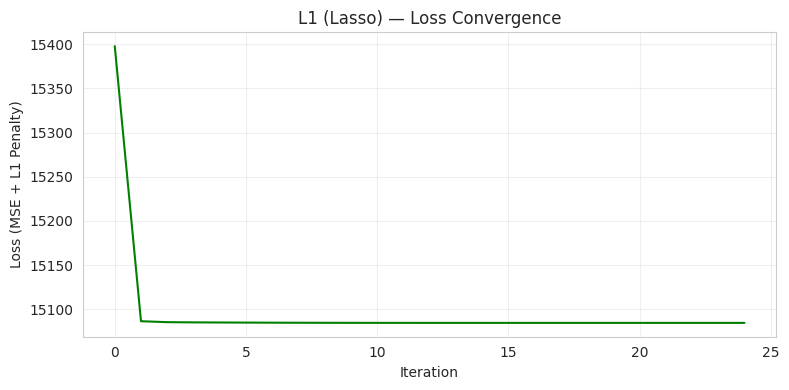

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(loss_l1, color='green', linewidth=1.5)
ax.set_title('L1 (Lasso) — Loss Convergence')
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss (MSE + L1 Penalty)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

###L2 Regularization (Ridge)

In [ ]:
def ridge_gradient_descent(X, y, alpha=1.0, lr=0.01, iterations=5000, tol=1e-6):
    """
    L2-Regularized Regression (Ridge) via Batch Gradient Descent.
    Loss = (1/n)*||Xw - y||² + alpha * ||w[1:]||²
    Gradient includes regularization term; bias (w[0]) is not regularized.
    """
    n, d = X.shape
    w = np.zeros(d)
    loss_history = []

    for it in range(iterations):
        y_pred = X @ w
        error = y_pred - y
        mse = np.mean(error ** 2)
        l2_penalty = alpha * np.sum(w[1:] ** 2)
        loss_history.append(mse + l2_penalty)

        # MSE gradient
        gradient = (2 / n) * (X.T @ error)

        # L2 regularization gradient (skip bias)
        reg_gradient = np.zeros(d)
        reg_gradient[1:] = 2 * alpha * w[1:]
        gradient = gradient + reg_gradient

        w = w - lr * gradient

        if it > 0 and abs(loss_history[-2] - loss_history[-1]) < tol:
            print(f"  L2 (Ridge) converged at iteration {it}")
            break

    return w, loss_history

print("Training Polynomial Regression + L2 (Ridge)...")
w_l2, loss_l2 = ridge_gradient_descent(X_train_poly_b, y_train, alpha=0.001, lr=0.1, iterations=5000)
print(f"  Iterations run: {len(loss_l2)}")

y_train_pred_l2 = X_train_poly_b @ w_l2
y_test_pred_l2 = X_test_poly_b @ w_l2

evaluate_model(y_train, y_train_pred_l2, "Poly + L2 (Ridge) — Training Set")
evaluate_model(y_test, y_test_pred_l2, "Poly + L2 (Ridge) — Test Set")

Training Polynomial Regression + L2 (Ridge)...
  L2 (Ridge) converged at iteration 417
  Iterations run: 418

--- Poly + L2 (Ridge) — Training Set ---
  MAE:  92.4147
  MSE:  14629.5439
  R²:   0.8776

--- Poly + L2 (Ridge) — Test Set ---
  MAE:  92.8499
  MSE:  14659.3897
  R²:   0.8777


(np.float64(92.84986697318533),
 np.float64(14659.389676783663),
 np.float64(0.8777310537285387))

###L2 Loss Convergence Plot

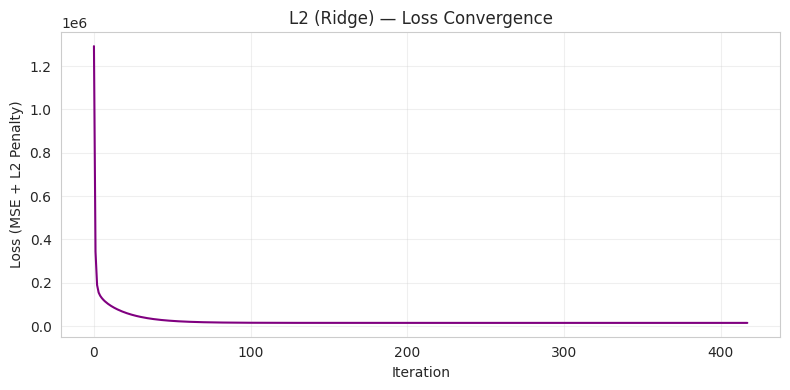

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(loss_l2, color='purple', linewidth=1.5)
ax.set_title('L2 (Ridge) — Loss Convergence')
ax.set_xlabel('Iteration')
ax.set_ylabel('Loss (MSE + L2 Penalty)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

###Comparison Table

In [ ]:
y_train_pred_linear = X_train_b @ w_bgd
y_test_pred_linear = X_test_b @ w_bgd

comparison = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'R²'],
    'Linear (Train)': [
        mean_absolute_error(y_train, y_train_pred_linear),
        mean_squared_error(y_train, y_train_pred_linear),
        r2_score(y_train, y_train_pred_linear)
    ],
    'Linear (Test)': [
        mean_absolute_error(y_test, y_test_pred_linear),
        mean_squared_error(y_test, y_test_pred_linear),
        r2_score(y_test, y_test_pred_linear)
    ],
    'Poly+L1 (Train)': [
        mean_absolute_error(y_train, y_train_pred_l1),
        mean_squared_error(y_train, y_train_pred_l1),
        r2_score(y_train, y_train_pred_l1)
    ],
    'Poly+L1 (Test)': [
        mean_absolute_error(y_test, y_test_pred_l1),
        mean_squared_error(y_test, y_test_pred_l1),
        r2_score(y_test, y_test_pred_l1)
    ],
    'Poly+L2 (Train)': [
        mean_absolute_error(y_train, y_train_pred_l2),
        mean_squared_error(y_train, y_train_pred_l2),
        r2_score(y_train, y_train_pred_l2)
    ],
    'Poly+L2 (Test)': [
        mean_absolute_error(y_test, y_test_pred_l2),
        mean_squared_error(y_test, y_test_pred_l2),
        r2_score(y_test, y_test_pred_l2)
    ],
})

display(comparison)

,Metric,Linear (Train),Linear (Test),Poly+L1 (Train),Poly+L1 (Test),Poly+L2 (Train),Poly+L2 (Test)
0,MAE,92.479520,92.848546,92.427385,92.839205,92.414733,92.849867
1,MSE,14644.142515,14663.640965,14632.885965,14655.021972,14629.543875,14659.389677
2,R²,0.877509,0.877696,0.877603,0.877767,0.877631,0.877731


###Weight Sparsity Table

In [ ]:
# Build feature names for polynomial terms
poly_names = key_inputs.copy()
for i in range(len(key_inputs)):
    for j in range(i, len(key_inputs)):
        if i == j:
            poly_names.append(f"{key_inputs[i]}²")
        else:
            poly_names.append(f"{key_inputs[i]} × {key_inputs[j]}")

print("L1 vs L2 — Learned Weights on Polynomial Features:\n")
print(f"{'Feature':<45} {'L1 Weight':>10} {'L2 Weight':>10} {'L1 Zeroed?':>12}")
print("-" * 80)
for k, name in enumerate(poly_names):
    w1 = w_l1[k + 1]
    w2 = w_l2[k + 1]
    zeroed = "  YES" if abs(w1) < 1e-8 else ""
    print(f"{name:<45} {w1:>10.4f} {w2:>10.4f} {zeroed:>12}")

print(f"\nL1 non-zero: {np.sum(np.abs(w_l1[1:]) > 1e-8)} / {len(w_l1) - 1}")
print(f"L2 non-zero: {np.sum(np.abs(w_l2[1:]) > 1e-8)} / {len(w_l2) - 1}")

L1 vs L2 — Learned Weights on Polynomial Features:

Feature                                        L1 Weight  L2 Weight   L1 Zeroed?
--------------------------------------------------------------------------------
Nitrogen_kg_ha                                  230.9391   231.0575             
Irrigation_Water_mm                             206.4231   206.6256             
Avg_Temperature_C                                 7.5359     8.0813             
Rainfall_mm                                       0.0000    -0.1869          YES
Humidity_%                                        0.4117     0.9111             
Nitrogen_kg_ha²                                   1.0192     1.3081             
Nitrogen_kg_ha × Irrigation_Water_mm              0.3626     0.6598             
Nitrogen_kg_ha × Avg_Temperature_C                0.0000    -0.2506          YES
Nitrogen_kg_ha × Rainfall_mm                      0.0000    -0.2055          YES
Nitrogen_kg_ha × Humidity_%                       0.0000 

###comparison & result visualization plots

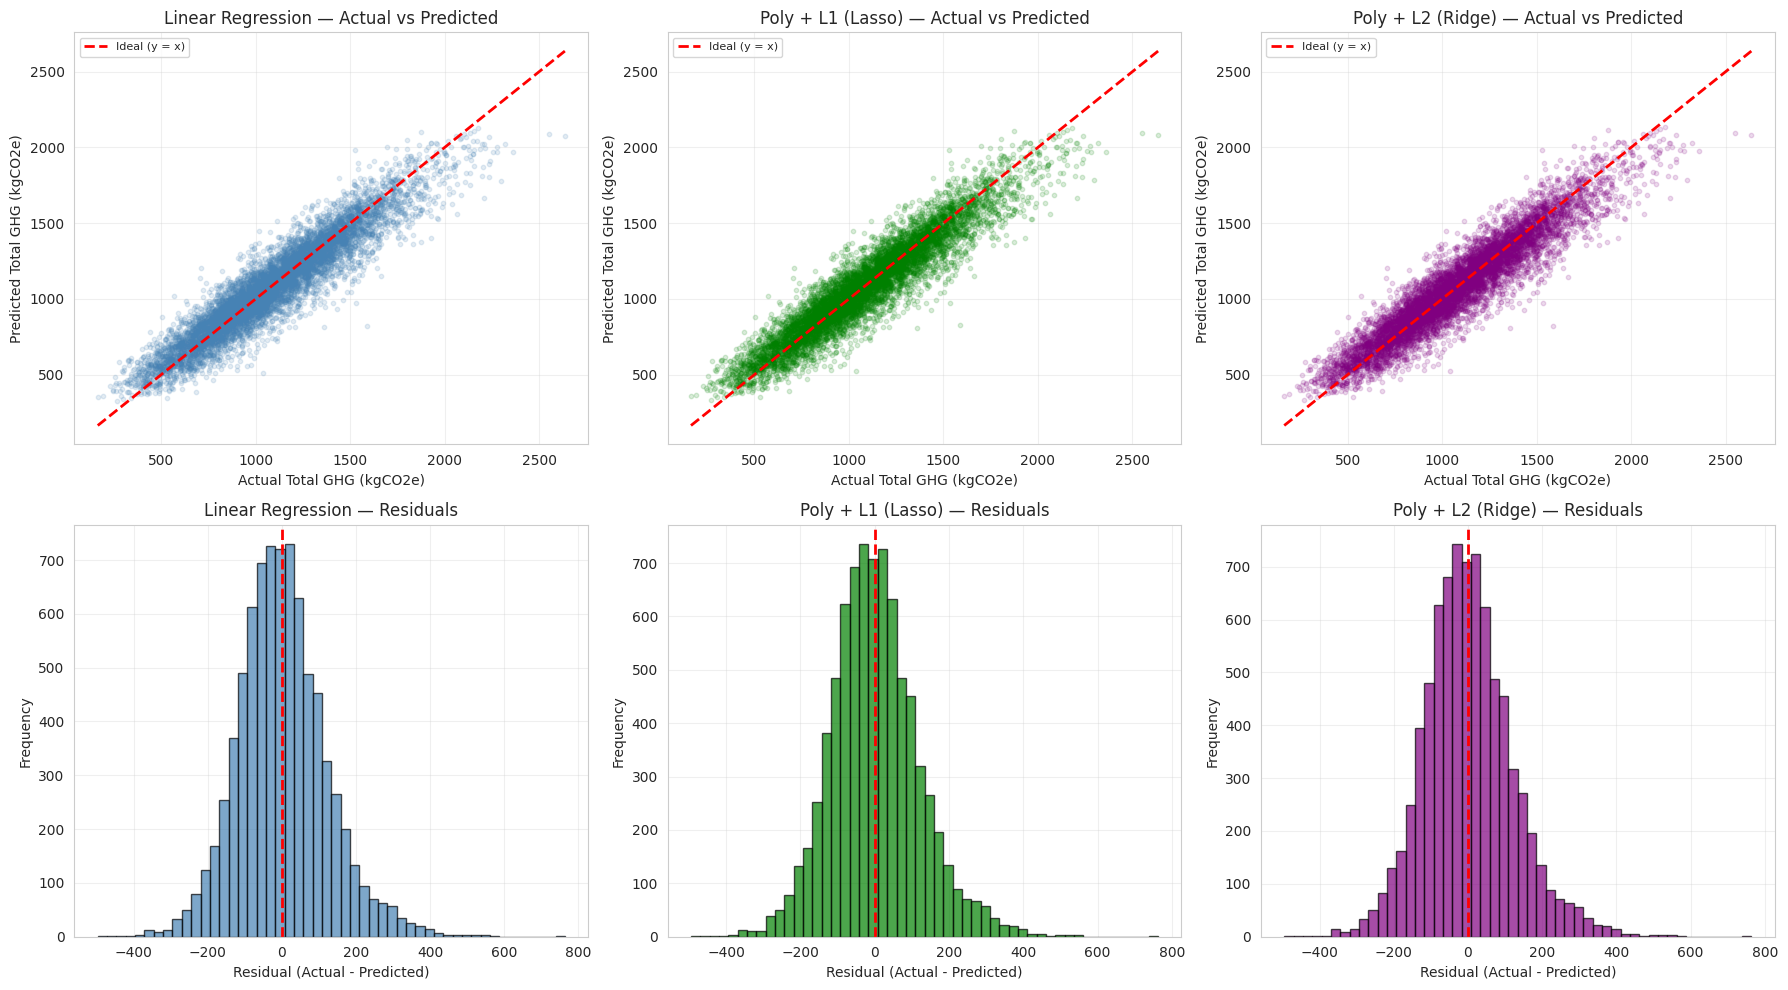

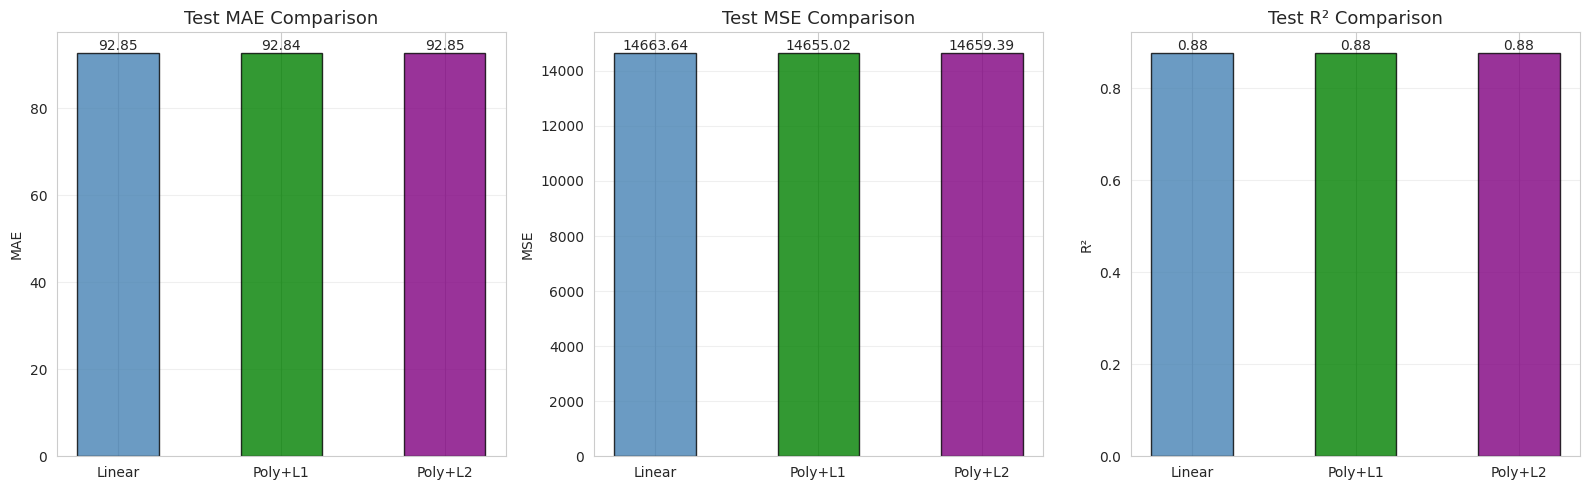

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- Row 1: Actual vs Predicted (Test Set) ---
models = [
    ('Linear Regression', y_test_pred_linear, 'steelblue'),
    ('Poly + L1 (Lasso)', y_test_pred_l1, 'green'),
    ('Poly + L2 (Ridge)', y_test_pred_l2, 'purple'),
]
for col, (name, preds, color) in enumerate(models):
    axes[0, col].scatter(y_test, preds, alpha=0.15, s=10, color=color)
    axes[0, col].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                      'r--', linewidth=2, label='Ideal (y = x)')
    axes[0, col].set_title(f'{name} — Actual vs Predicted')
    axes[0, col].set_xlabel('Actual Total GHG (kgCO2e)')
    axes[0, col].set_ylabel('Predicted Total GHG (kgCO2e)')
    axes[0, col].legend(fontsize=8)
    axes[0, col].grid(True, alpha=0.3)

# --- Row 2: Residual Distributions (Test Set) ---
for col, (name, preds, color) in enumerate(models):
    residuals = y_test - preds
    axes[1, col].hist(residuals, bins=50, color=color, edgecolor='black', alpha=0.7)
    axes[1, col].axvline(x=0, color='red', linestyle='--', linewidth=2)
    axes[1, col].set_title(f'{name} — Residuals')
    axes[1, col].set_xlabel('Residual (Actual - Predicted)')
    axes[1, col].set_ylabel('Frequency')
    axes[1, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Metric Bar Chart ---
metric_names = ['MAE', 'MSE', 'R²']
linear_vals = [mean_absolute_error(y_test, y_test_pred_linear),
               mean_squared_error(y_test, y_test_pred_linear),
               r2_score(y_test, y_test_pred_linear)]
l1_vals = [mean_absolute_error(y_test, y_test_pred_l1),
           mean_squared_error(y_test, y_test_pred_l1),
           r2_score(y_test, y_test_pred_l1)]
l2_vals = [mean_absolute_error(y_test, y_test_pred_l2),
           mean_squared_error(y_test, y_test_pred_l2),
           r2_score(y_test, y_test_pred_l2)]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x_pos = np.arange(3)
width = 0.25

for i, metric in enumerate(metric_names):
    vals = [linear_vals[i], l1_vals[i], l2_vals[i]]
    colors = ['steelblue', 'green', 'purple']
    labels = ['Linear', 'Poly+L1', 'Poly+L2']
    bars = axes[i].bar(labels, vals, color=colors, width=0.5, edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Test {metric} Comparison', fontsize=13)
    axes[i].set_ylabel(metric)
    axes[i].grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                     f'{val:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

Summary: Performance Differences and Effects of Model Complexity

All three models achieve very similar R² scores on the test set (~0.877). The polynomial features (degree 2) did not meaningfully improve prediction accuracy. This tells us the relationship between the input features and Total GHG emissions is fundamentally linear — the squared and interaction terms don't capture significant additional patterns.

L1 (Lasso) Regularization:
Lasso aggressively zeroed out 15 of the 20 polynomial features, keeping only 5 non-zero weights — primarily Nitrogen, Irrigation Water, and their squared terms. This confirms that most interaction and squared terms are irrelevant. Lasso's built-in feature selection is valuable here: it automatically identified which polynomial terms actually matter.

L2 (Ridge) Regularization:
Ridge kept all 20 weights non-zero but shrank them. It achieved slightly lower R² than Lasso because it distributes weight across all features (including noisy ones) rather than eliminating them. This is the key difference: L2 shrinks, L1 selects.

Key Takeaway:
For this dataset, the added model complexity from polynomial features provides negligible improvement. The regularized models prevent overfitting to the extra terms, but since the base relationship is already well-captured by a simple linear model (R² ≈ 0.877), the polynomial expansion adds complexity without benefit.

#5) Classification Reformulation

### Discretize Target Variable

Convert the continuous 'Total_GHG_kgCO2e' target variable into a categorical variable with two classes ('Low', 'High') using quantile-based binning to ensure balanced classes for the classification task. Then the target is split into training and testing sets once again.

In [ ]:
threshold = df[TARGET].median()

df['Emission_Class'] = np.where(
    df[TARGET] <= threshold,
    0,   # Low
    1    # High
)

y_class = df['Emission_Class'].values

y_train = y_class[train_idx]
y_test = y_class[test_idx]

###Logistic Regression

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [ ]:
def train_logistic_binary(X, y, lr=0.01, iterations=1000):
    m, n = X.shape
    w = np.zeros(n)

    for it in range(iterations):
        z = X @ w
        y_hat = sigmoid(z)

        gradient = (X.T @ (y_hat - y)) / m
        w -= lr * gradient

    return w

w = train_logistic_binary(X_train_b, y_train, lr=0.1, iterations=2000)

In [ ]:
def predict_binary(X, w):
    probs = sigmoid(X @ w)
    return (probs >= 0.5).astype(int)

####Accuracy

In [ ]:
y_lr_train_pred = predict_binary(X_train_b, w)
train_acc = np.mean(y_lr_train_pred == y_train)

y_lr_test_pred = predict_binary(X_test_b, w)
test_acc = np.mean(y_lr_test_pred == y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 0.89509375
Testing Accuracy: 0.8975


The Logistic Regression model achieved strong performance, with a training accuracy of approximately 89.51% and a testing accuracy of 89.75%. This indicates that the model generalizes well to unseen data and does not overfit considering similar accuracy in both datasets.

####Confusion Matrix

In [ ]:
def confusion_matrix_binary(y_true, y_pred):
    cm = np.zeros((2, 2))
    for i in range(len(y_true)):
        cm[y_true[i], y_pred[i]] += 1
    return cm

cm_lr = confusion_matrix_binary(y_test, y_lr_test_pred)

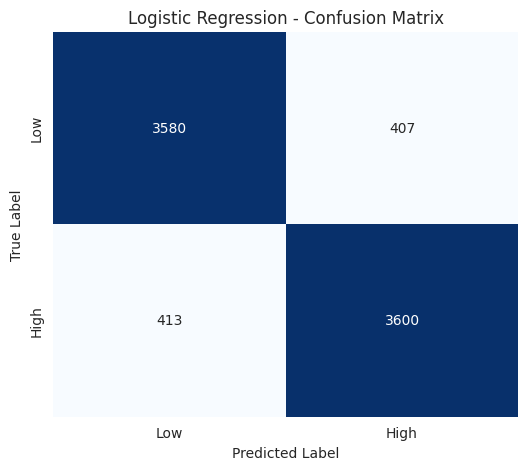

In [ ]:
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='g', cmap='Blues', cbar=False,
            xticklabels=['Low', 'High'],
            yticklabels=['Low', 'High'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Logistic Regression - Confusion Matrix')
plt.show()

The confusion matrix shows strong performance by the Logistic Regression model. It accurately predicted 'Low' emissions 3580 times (True Negatives) and 'High' emissions 3600 times (True Positives), demonstrating its ability to distinguish between the two emission classes with a high degree of success.

####Precision, Recall, F1

In [ ]:
TN, FP = cm_lr[0]
FN, TP = cm_lr[1]

precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

Precision: 0.8984277514349888
Recall: 0.897084475454772
F1: 0.8977556109725685


A precision of approximately 89.8% indicates that when the model predicts 'High' emissions, it is correct most of the time. A recall of about 89.7% shows that the model successfully identifies the vast majority of actual 'High' emission cases. The F1-score of 89.77% confirms a good balance between precision and recall, suggesting the model is effective at both accurately predicting positive cases and finding most of the positive cases.

###Naive Bayes

In [ ]:
def train_naive_bayes(X, y):
    classes = np.unique(y)
    n_features = X.shape[1]

    means = {}
    variances = {}
    priors = {}

    for c in classes:
        X_c = X[y == c]

        means[c] = X_c.mean(axis=0)
        variances[c] = X_c.var(axis=0) + 1e-9  # avoid division by zero
        priors[c] = X_c.shape[0] / X.shape[0]

    return means, variances, priors

means, variances, priors = train_naive_bayes(X_train_b, y_train)

In [ ]:
def gaussian_log_likelihood(x, mean, var):
    return -0.5 * np.log(2 * np.pi * var) - ((x - mean) ** 2) / (2 * var)

In [ ]:
def predict_naive_bayes(X, means, variances, priors):
    predictions = []

    for x in X:
        log_posteriors = []

        for c in means.keys():
            log_prior = np.log(priors[c])
            log_likelihood = gaussian_log_likelihood(x, means[c], variances[c]).sum()

            log_posteriors.append(log_prior + log_likelihood)

        predictions.append(np.argmax(log_posteriors))

    return np.array(predictions)

y_nb_pred = predict_naive_bayes(X_test_b, means, variances, priors)

####Accuracy

In [ ]:
accuracy = np.mean(y_nb_pred == y_test)
print("Accuracy:", accuracy)

Accuracy: 0.88975


The model demonstrated high accuracy with a score of around 89%.

####Confusion Matrix


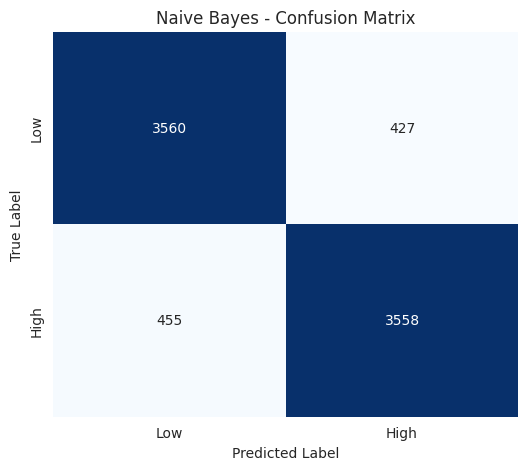

In [ ]:
cm_nb = confusion_matrix_binary(y_test, y_nb_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_nb, annot=True, fmt='g', cmap='Blues', cbar=False,
            xticklabels=['Low', 'High'],
            yticklabels=['Low', 'High'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Naive Bayes - Confusion Matrix')
plt.show()

The Naive Bayes confusion matrix indicates a strong performance in distinguishing between emission classes. It correctly classified 'Low' emissions 3560 times and 'High' emissions 3558 times, showing a balanced ability to identify both categories.





####Precision, Recall, F1

In [ ]:
TN, FP = cm_nb[0]
FN, TP = cm_nb[1]

precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

Precision: 0.8928481806775408
Recall: 0.8866184899077997
F1: 0.889722430607652


A precision of approximately 89.2% indicates that when the model predicts 'High' emissions, it is correct most of the time. A recall of about 88.6% shows that the model successfully identifies the vast majority of actual 'High' emission cases. The F1-score of 88.9% confirms a good balance between precision and recall, suggesting the model is effective at both accurately predicting positive cases and finding most of the positive cases.

###Perceptron

In [ ]:
def perceptron_train(X_train, y_train, learning_rate=0.01, iterations=200):

    n_samples, n_features = X_train.shape


    w = np.zeros(n_features)
    b = 0

    for _ in range(iterations):
        for i in range(n_samples):

            linear_output = np.dot(X_train[i], w) + b
            prediction = 1 if linear_output >= 0 else 0

            if prediction != y_train[i]:
                error = y_train[i] - prediction
                w += learning_rate * error * X_train[i]
                b += learning_rate * error

    return w, b

w_perc, b_perc = perceptron_train(X_train_b, y_train, learning_rate=0.01, iterations=200)

In [ ]:
def perceptron_predict(X, w, b):
    linear_output = np.dot(X, w) + b
    return np.where(linear_output >= 0, 1, 0)

In [ ]:
y_train_pred_perc = perceptron_predict(X_train_b, w_perc, b_perc)
y_test_pred_perc = perceptron_predict(X_test_b, w_perc, b_perc)

####Accuracy

In [ ]:
perc_train_acc = np.mean(y_train_pred_perc == y_train)
perc_test_acc = np.mean(y_test_pred_perc == y_test)

print("Training Accuracy:", perc_train_acc)
print("Testing Accuracy:", perc_test_acc)

Training Accuracy: 0.83275
Testing Accuracy: 0.836125


The Perceptron model achieved strong performance, with a training accuracy of approximately 83.27% and a testing accuracy of 83.61. This indicates that the model generalizes well to unseen data and does not overfit considering similar accuracy in both datasets.

Confusion Matrix

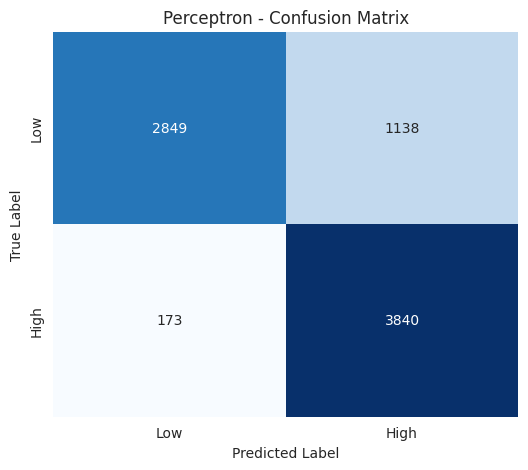

In [ ]:
cm_perc = confusion_matrix_binary(y_test, y_test_pred_perc)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_perc, annot=True, fmt='g', cmap='Blues', cbar=False,
            xticklabels=['Low', 'High'],
            yticklabels=['Low', 'High'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Perceptron - Confusion Matrix')
plt.show()

Based on the Perceptron's confusion matrix, the model accurately identified 2849 instances as 'Low' (True Negatives) and 3840 instances as 'High' (True Positives). The model incorrectly classified 1138 'Low' instances as 'High' (False Positives) and 173 'High' instances as 'Low' (False Negatives). This indicates a strong performance, particularly in identifying 'High' emissions, with a relatively low number of False Negatives.

####Precision, Recall, F1

In [ ]:
TN, FP = cm_perc[0]
FN, TP = cm_perc[1]

precision = TP / (TP + FP)
recall = TP / (TP + FN)
f1 = 2 * (precision * recall) / (precision + recall)

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

Precision: 0.7713941341904379
Recall: 0.9568901071517568
F1: 0.8541875208541876


For the Perceptron model, a precision of approximately 77.14% indicates that when it predicts 'High' emissions, it is correct about 77.14% of the time. A high recall of about 95.68% suggests the model is very good at identifying most of the actual 'High' emission cases. The F1-score of roughly 85.4% reflects a strong overall balance between precision and recall for this binary classification.

###Model Comparison

In [ ]:
TN_lr, FP_lr = cm_lr[0]
FN_lr, TP_lr = cm_lr[1]

precision_lr = TP_lr / (TP_lr + FP_lr)
recall_lr = TP_lr / (TP_lr + FN_lr)
f1_lr = 2 * (precision_lr * recall_lr) / (precision_lr + recall_lr)

TN_nb, FP_nb = cm_nb[0]
FN_nb, TP_nb = cm_nb[1]

precision_nb = TP_nb / (TP_nb + FP_nb)
recall_nb = TP_nb / (TP_nb + FN_nb)
f1_nb = 2 * (precision_nb * recall_nb) / (precision_nb + recall_nb)

TN_perc, FP_perc = cm_perc[0]
FN_perc, TP_perc = cm_perc[1]

precision_perc = TP_perc / (TP_perc + FP_perc)
recall_perc = TP_perc / (TP_perc + FN_perc)
f1_perc = 2 * (precision_perc * recall_perc) / (precision_perc + recall_perc)

comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Logistic Regression': [
        test_acc,
        precision_lr,
        recall_lr,
        f1_lr
    ],
    'Naive Bayes': [
        accuracy,
        precision_nb,
        recall_nb,
        f1_nb
    ],
    'Perceptron': [
        perc_test_acc,
        precision_perc,
        recall_perc,
        f1_perc
    ]
})

display(comparison_df)


,Metric,Logistic Regression,Naive Bayes,Perceptron
0,Accuracy,0.897500,0.889750,0.836125
1,Precision,0.898428,0.892848,0.771394
2,Recall,0.897084,0.886618,0.956890
3,F1-score,0.897756,0.889722,0.854188


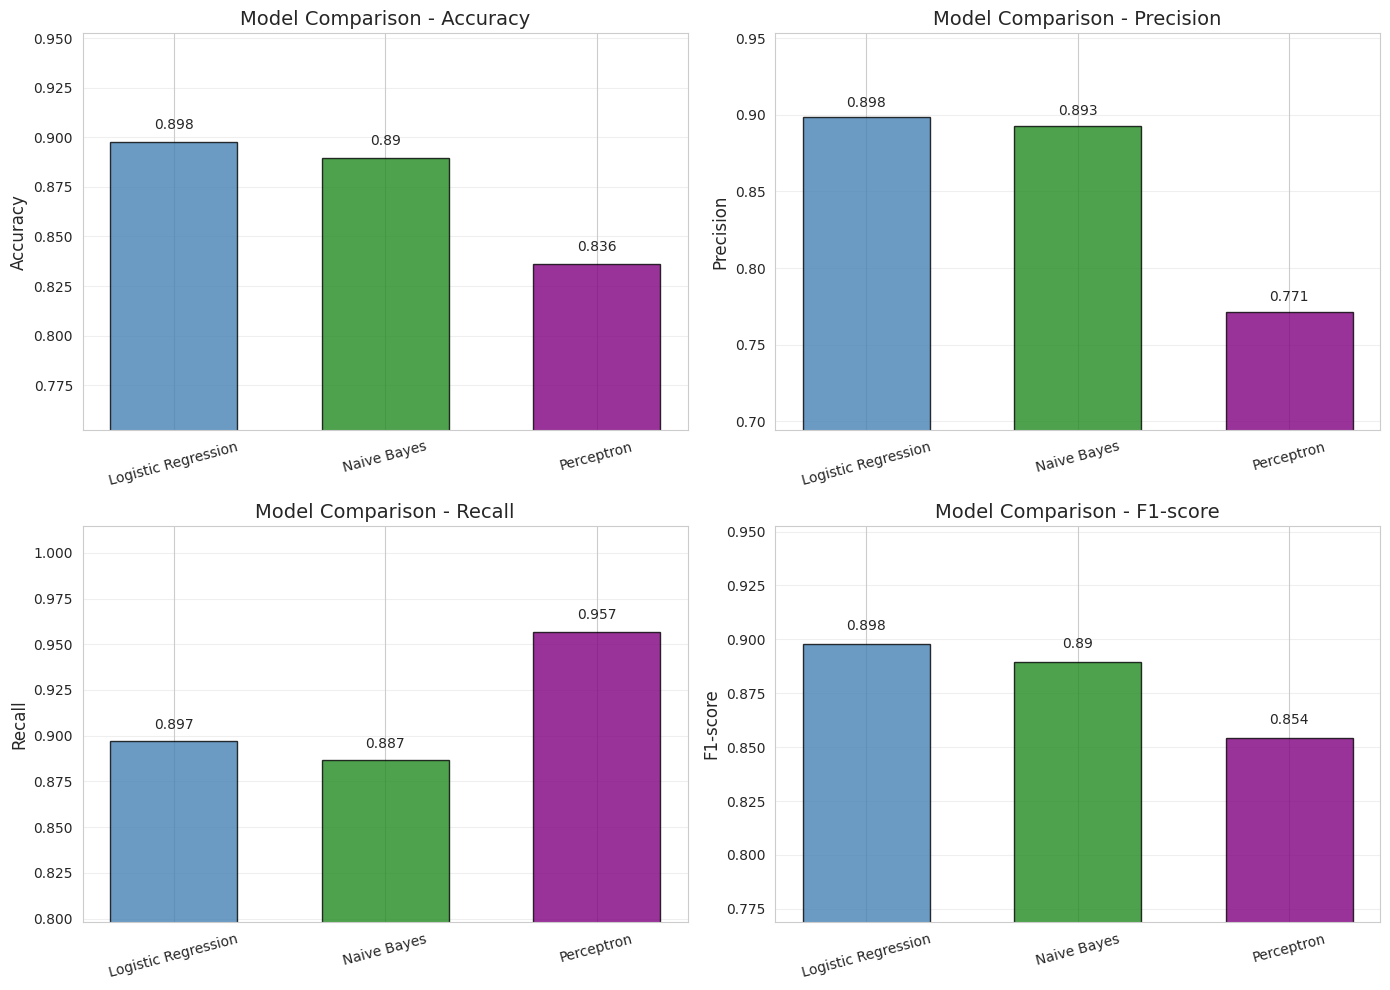

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten() # Flatten the 2x2 array of axes for easy iteration

model_names = ['Logistic Regression', 'Naive Bayes', 'Perceptron']
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score']

for i, metric in enumerate(metrics):
    ax = axes[i]
    # Extract values for the current metric for each model
    metric_values = comparison_df[comparison_df['Metric'] == metric].iloc[0, 1:].values

    # Create bar chart
    bars = ax.bar(model_names, metric_values, color=['steelblue', 'forestgreen', 'purple'], width=0.6, edgecolor='black', alpha=0.8)

    # Set title and labels
    ax.set_title(f'Model Comparison - {metric}', fontsize=14)
    ax.set_ylabel(metric, fontsize=12)
    ax.tick_params(axis='x', rotation=15) # Rotate x-axis labels for better readability
    ax.grid(True, alpha=0.3, axis='y')

    # Add value labels on top of bars
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.005, round(yval, 3),
                ha='center', va='bottom', fontsize=10)

    # Set y-axis limits for better comparison, especially for metrics around 0.8-0.9
    if metric in ['Accuracy', 'Precision', 'Recall', 'F1-score']:
        ax.set_ylim(min(metric_values) * 0.9, max(metric_values) * 1.05 + 0.01)

plt.tight_layout()
plt.show()

Logistic Regression achieved the highest accuracy and a very high precision and F1-score, suggesting it's a balanced and reliable model for distinguishing between 'Low' and 'High' greenhouse gas emissions. Naive Bayes also performed very well, with comparable F1-scores and slightly lower accuracy, indicating its strong overall balance. The Perceptron model, while exceptional at identifying actual 'High' emission cases due to its high recall, had lower accuracy and precision, leading to more false alarms. Ultimately, the best model depends on the specific cost associated with false positives versus false negatives in practical applications.

**Strengths of Classification Approach:**
*   **Simplicity and Interpretability:** By categorizing GHG emissions into 'Low' and 'High', the model outputs become more straightforward to understand and communicate.
*   **Decision-Making:** This approach directly supports categorical decision-making scenarios. For instance, it can help classify agricultural practices as 'high-risk' or 'low-risk' for emissions.
*   **Robustness to Noise:** Discretization can sometimes make the models more robust to outliers or noise in the continuous target variable.

**Limitations of Classification Approach**
*   **Information Loss:** By reducing a spectrum of values to just two categories, we lose the granularity of actual emission levels. For example, a farm with emissions just below the 'High' threshold is treated the same as one with very low emissions, and a farm slightly above the threshold is grouped with one producing extremely high emissions.
*   **Arbitrary Thresholds:** The choice of the median as a threshold for 'Low' and 'High' is somewhat arbitrary. Different thresholds could lead to different classifications and model performances, and there's no inherent 'natural' breakpoint in the continuous data.

In summary, while the classification approach sacrifices the fine-grained detail of a regression model, it provides clear, actionable insights for binary decision-making contexts related to greenhouse gas emissions.